In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patheffects import withStroke
import geopandas as gpd
from netCDF4 import Dataset
import os
# import cv2
import datetime
import numba
import pickle
from shapely.geometry import Point, Polygon
import inspect
import glob
import h5py

import track

# Extract META Data

In [2]:
lonmin = 140 - 2.5
lonmax = 180 + 2.5
latmin = 28  - 2.5
latmax = 40  + 2.5

track.lonmin = lonmin
track.lonmax = lonmax
track.latmin = latmin
track.latmax = latmax

In [3]:
# path = '/Users/jjijack/Documents/Visual Studio Code/Python/EddyNet/META-Data-Converter/'
path = '../META3.1/'

ACS, ACL, CS, CL = track.load_meta_data(path)

In [4]:
track.process_and_save(ACS, 'acs.pkl')
track.process_and_save(ACL, 'acl.pkl')
track.process_and_save(CS, 'cs.pkl')
track.process_and_save(CL, 'cl.pkl')

ACS count: 6738
ACL count: 13597
CS count: 7096
CL count: 15072


# Extract Mat Data

In [ ]:
Float_path = './Argo_addFloat'
paths = []

Float_path = './Argo_addFloat'
paths = [os.path.join(Float_path, f'Argo2014_{month}.mat') for month in range(1, 13)]

print(paths)

['./Argo_addFloat/Argo2014_1.mat', './Argo_addFloat/Argo2014_2.mat', './Argo_addFloat/Argo2014_3.mat', './Argo_addFloat/Argo2014_4.mat', './Argo_addFloat/Argo2014_5.mat', './Argo_addFloat/Argo2014_6.mat', './Argo_addFloat/Argo2014_7.mat', './Argo_addFloat/Argo2014_8.mat', './Argo_addFloat/Argo2014_9.mat', './Argo_addFloat/Argo2014_10.mat', './Argo_addFloat/Argo2014_11.mat', './Argo_addFloat/Argo2014_12.mat']


In [ ]:
# 定义列名
columns = [
    "Year", "Month", "Day", "Longitude", "Latitude", "Depth_m", "DO_mol_kg", "Salinity_psu",
    "Temperature_degC", "Oxygen_flag", "Oxygen_flag2", "Profile_number", "Datasets_number",
    "Platform_number", "Cycle_number", "Float_serial_no"
]

# 初始化空列表用于存储所有 DataFrame
all_data = []

for path in paths:
    try:
        with h5py.File(path, 'r') as f:
            if 'do' in f:
                do_data = f['do'][:].T  # 转置为行优先格式
                df = pd.DataFrame(do_data, columns=columns)
                all_data.append(df)
            else:
                print(f"'do' not found in {path}")
    except Exception as e:
        print(f"Failed to read {path}: {e}")

# 合并所有月份的数据
final_df = pd.concat(all_data, ignore_index=True)

# 保存
# final_df.to_csv("Argo2014.csv", index=False)
final_df.to_parquet("Argo2014.parquet", index=False)

print("All data successfully saved!")

All data successfully saved!


# Read Mat Data

In [ ]:
argo_data = pd.read_parquet("Argo2014.parquet")
np.unique(argo_data["Datasets_number"]) #datasets_number==1 means Argo data
argo_data = argo_data.drop(columns=['Salinity_psu', 'Oxygen_flag', 'Oxygen_flag2', 'Datasets_number', 'Cycle_number', 'Float_serial_no'])

In [ ]:
argo_data

,Year,Month,Day,Longitude,Latitude,Depth_m,DO_mol_kg,Temperature_degC,Profile_number,Platform_number
0,2014.0,1.0,1.0,28.659855,42.344217,0.500000,308.346802,9.475,34383.0,7900591.0
1,2014.0,1.0,1.0,28.659855,42.344217,1.500000,308.055176,9.477,34383.0,7900591.0
2,2014.0,1.0,1.0,28.659855,42.344217,2.600000,307.280914,9.477,34383.0,7900591.0
3,2014.0,1.0,1.0,28.659855,42.344217,3.700000,306.721008,9.476,34383.0,7900591.0
4,2014.0,1.0,1.0,28.659855,42.344217,4.900000,305.976624,9.482,34383.0,7900591.0
...,...,...,...,...,...,...,...,...,...,...
2907959,2014.0,12.0,29.0,4.161000,70.146000,1751.430054,312.416504,-0.579,230331.0,6902550.0
2907960,2014.0,12.0,29.0,4.161000,70.146000,1801.670044,311.425629,-0.600,230331.0,6902550.0
2907961,2014.0,12.0,29.0,4.161000,70.146000,1851.569946,310.973022,-0.617,230331.0,6902550.0
2907962,2014.0,12.0,29.0,4.161000,70.146000,1901.339966,309.940399,-0.637,230331.0,6902550.0


# Find META Track

In [2]:
with open('acs.pkl', 'rb') as f:
    acs = pickle.load(f)

with open('acl.pkl', 'rb') as f:
    acl = pickle.load(f)

with open('cs.pkl', 'rb') as f:
    cs = pickle.load(f)

with open('cl.pkl', 'rb') as f:
    cl = pickle.load(f)

/dssg/home/acct-kangdj/kangdj-user1/Oxygen/track.py:187: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


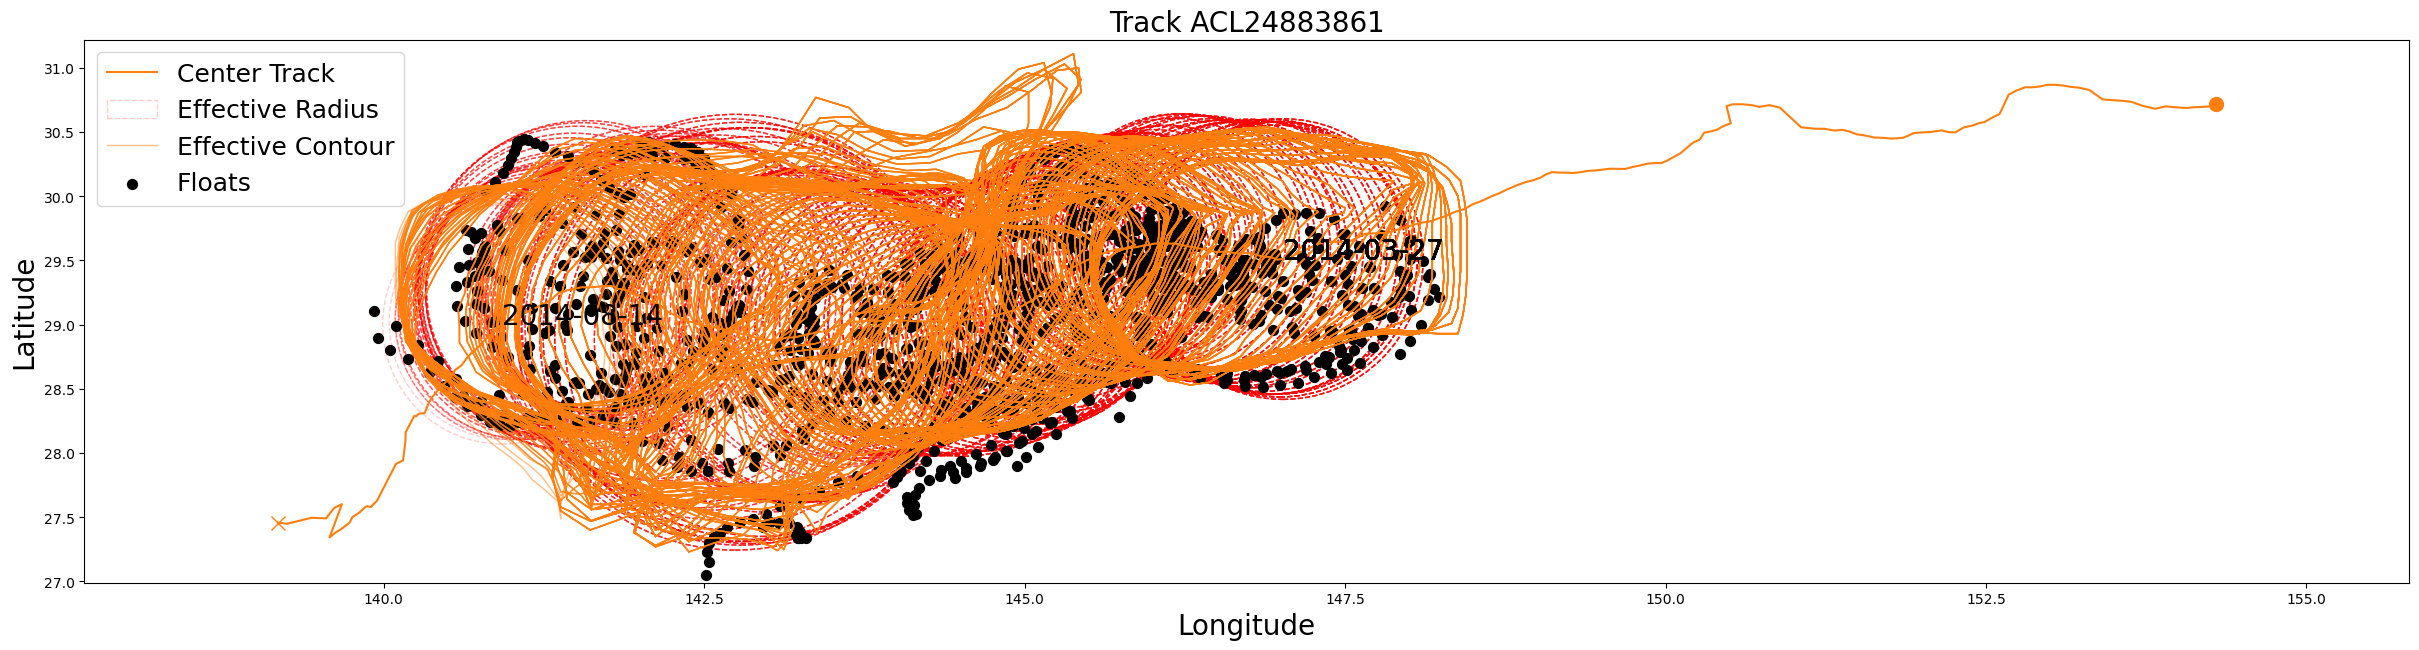

In [3]:
track.plot_track(acl, 24883861)

# Read GLORYS Data

In [7]:
Glorys_path = '../copernicus/GLORYS'
test_path = os.path.join(Glorys_path, test_date.strftime("%Y"), test_date.strftime("%m"), 'mercatorglorys12v1_gl12_mean_')
test_path += test_date.strftime("%Y%m%d")
matches = glob.glob(test_path + '_R*')
if matches:
    test_path = matches[0]
    print("Matching file:", test_path)
else:
    print("No matching file found.")

Matching file: ../copernicus/GLORYS/2014/03/mercatorglorys12v1_gl12_mean_20140327_R20140402.nc


In [8]:
test_Glorys = Dataset(test_path)
for var in test_Glorys.variables:
    print(var,test_Glorys.variables[var].standard_name)
    print(test_Glorys.variables[var].dimensions,test_Glorys.variables[var].shape)

longitude longitude
('longitude',) (4320,)
latitude latitude
('latitude',) (2041,)
depth depth
('depth',) (50,)
time time
('time',) (1,)
mlotst ocean_mixed_layer_thickness_defined_by_sigma_theta
('time', 'latitude', 'longitude') (1, 2041, 4320)
zos sea_surface_height_above_geoid
('time', 'latitude', 'longitude') (1, 2041, 4320)
bottomT sea_water_potential_temperature_at_sea_floor
('time', 'latitude', 'longitude') (1, 2041, 4320)
sithick sea_ice_thickness
('time', 'latitude', 'longitude') (1, 2041, 4320)
siconc sea_ice_area_fraction
('time', 'latitude', 'longitude') (1, 2041, 4320)
usi eastward_sea_ice_velocity
('time', 'latitude', 'longitude') (1, 2041, 4320)
vsi northward_sea_ice_velocity
('time', 'latitude', 'longitude') (1, 2041, 4320)
thetao sea_water_potential_temperature
('time', 'depth', 'latitude', 'longitude') (1, 50, 2041, 4320)
so sea_water_salinity
('time', 'depth', 'latitude', 'longitude') (1, 50, 2041, 4320)
uo eastward_sea_water_velocity
('time', 'depth', 'latitude', 'lo

In [9]:
lon = test_Glorys.variables['longitude'][:]
lat = test_Glorys.variables['latitude'][:]
depth = test_Glorys.variables['depth'][:]
thetao = test_Glorys.variables['thetao'][0,0,:,:]

In [10]:
from matplotlib.path import Path

# 构造封闭多边形(使用test_eddy中的轮廓坐标)
polygon = Path(np.column_stack((test_eddy[6], test_eddy[7])))

# 生成二维经纬度网格，注意: lon 和 lat 已定义为一维数组
LON, LAT = np.meshgrid(lon, lat)

# 判断网格内的点是否在多边形内
points = np.vstack((LON.ravel(), LAT.ravel())).T
inside = polygon.contains_points(points).reshape(LON.shape)

# 用掩码提取thetao中在多边形内部的区域，其外部设为nan
thetao_region = np.where(inside, thetao, np.nan)



In [11]:
test_float=track.filtered_float_data(acl, 24883861)

In [12]:
test_float_filtered = test_float[(test_float['Month'] == test_date.month) & (test_float['Day'] == test_date.day)]

In [13]:
test_float_filtered

,Year,Month,Day,Longitude,Latitude,ProfileNumber,Dataset,DO_mean(umol/kg),DO_min(umol/kg),DO_max(umol/kg),Depth_min(m),Depth_max(m),Eddy
3896,2014.0,3.0,27.0,146.8727,29.2586,42771.0,argo,197.898067,169.597107,220.436951,0.400000,591.900024,AC
3897,2014.0,3.0,27.0,146.8730,29.2590,34545.0,WOD_PFL,201.434199,171.524994,225.311005,0.397301,587.066895,AC
3898,2014.0,3.0,27.0,146.8940,29.5009,42507.0,argo,193.707232,98.643906,219.879578,0.400000,825.400024,AC
3899,2014.0,3.0,27.0,146.8940,29.5010,34484.0,WOD_PFL,197.035168,99.468002,224.628006,0.397293,818.186707,AC
3900,2014.0,3.0,27.0,147.1290,29.2690,34606.0,WOD_PFL,211.158158,186.690002,225.884003,0.397300,450.937408,AC
3901,2014.0,3.0,27.0,147.1290,29.2694,43028.0,argo,207.189816,183.804794,221.031723,0.400000,454.500000,AC
3902,2014.0,3.0,27.0,147.1646,29.5167,42247.0,argo,196.577935,115.397675,221.358734,1.100000,791.599976,AC
3903,2014.0,3.0,27.0,147.1650,29.5170,34423.0,WOD_PFL,199.996044,116.357002,226.266006,1.092553,784.744507,AC
3904,2014.0,3.0,27.0,147.2238,29.7277,39208.0,argo,188.025072,65.949509,217.801270,0.300000,895.400024,AC
3905,2014.0,3.0,27.0,147.2240,29.7280,33508.0,WOD_PFL,191.400765,66.573997,222.751007,0.297965,887.410461,AC


/tmp/ipykernel_2535703/1175299194.py:4: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(label='thetao')


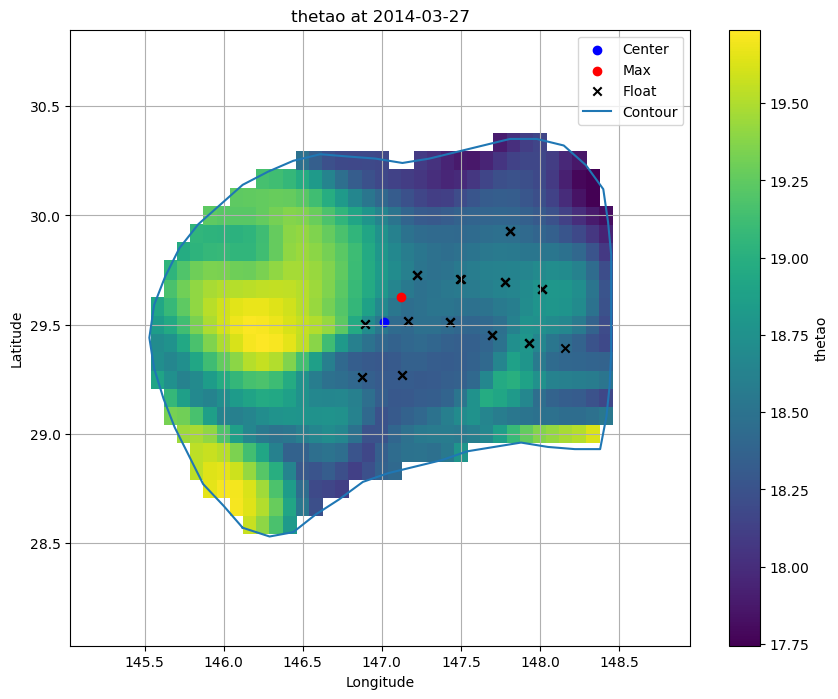

In [14]:
# 可视化提取结果
plt.figure(figsize=(10, 8))
plt.pcolor(lon, lat, thetao_region, shading='auto')
plt.colorbar(label='thetao')
plt.scatter(test_eddy[2], test_eddy[3], label='Center', color='blue')
plt.scatter(test_eddy[4], test_eddy[5], label='Max', color='red')
plt.scatter(test_float_filtered['Longitude'], test_float_filtered['Latitude'], label='Float', color='black', marker='x')
plt.plot(test_eddy[6], test_eddy[7], label='Contour')
plt.xlim([min(test_eddy[6])-0.5, max(test_eddy[6])+0.5])
plt.ylim([min(test_eddy[7])-0.5, max(test_eddy[7])+0.5])
plt.title(f'thetao at {test_date.strftime("%Y-%m-%d")}')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid()
plt.show()